In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import numpy.linalg as LA

from scipy.signal import butter, lfilter, lfilter_zi

import tensorflow as tf
from tensorflow import keras

import pandas as pd

In [46]:
#Low pass filtering

def butter_lpf_setup(cutoff, fs, order):
    nyq = 0.5 * fs
    normal_cutoff = cutoff/nyq
    b,a = butter(order, normal_cutoff, btype='low', analog=False)
    
    #initial conditions for the filter
    zi = lfilter_zi(b,a)
    return b,a,zi

def butter_lpf(data,b,a,zi):
    y,_ = lfilter(b,a,data,zi=zi*data[0])
    return y

In [47]:
#Generate Filtered Normed Trajectories

#3 state linear system

def three_state(x,t,a,b):
    A = np.diag([-a,-b,-(a-b)])
    #print(A.shape)
    #print(x.shape)
    x_dot = np.dot(A,x.reshape(-1,1))
    return x_dot.squeeze()

#initial conditions
x0 = [2,4,6]  #[x1,x2,x3]

#generate time vector
num_points = 301
t = np.linspace(0,30,num_points)

#min and max parameter values
amin = -0.5
amax = 0.5
bmin = -0.5
bmax = 0.5

#number of trajectories to generate
n_traj = 5000

X_filtered = np.empty((n_traj,num_points))
X = np.empty((n_traj,num_points))

#low pass filter
fs = t[1]-t[0]
order = 2
cutoff = fs/1000

b_lpf,a_lpf,zi = butter_lpf_setup(cutoff, fs, order)

params = []

for i in range(0,n_traj):
    #sample parameters uniformly
    a = np.random.uniform(amin,amax)
    b = np.random.uniform(bmin,bmax)
    
    params.append([a,b])
    
    #solve the system
    x_ = odeint(three_state, x0, t, args=(a,b))
    
    #compute the norm
    x_norm_ = LA.norm(x_,ord=2,axis=1).squeeze()
    X[i,:] = (x_norm_ - np.mean(x_norm_))/np.std(x_norm_)
    
    #low pass filter the normed states
    #x_norm_lpf_ = butter_lpf(x_norm_,b_lpf,a_lpf,zi)
    
    #normalize the filtered norm trajectories and store
    #X_filtered[i,:] = (x_norm_lpf_ - np.mean(x_norm_lpf_))/np.std(x_norm_lpf_)

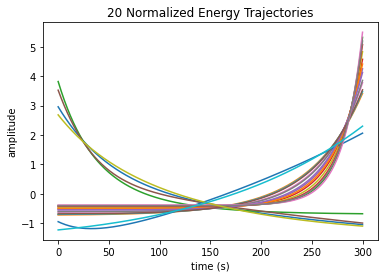

In [48]:
plt.plot(X[:20].transpose())
plt.title('20 Normalized Energy Trajectories')
plt.xlabel('time (s)')
plt.ylabel('amplitude')

#save figure
plt.savefig('normalized_energy_trajectory_samples.png')

plt.show()

In [49]:
#split data into training and testing sets

test_idx = int(np.floor(n_traj * 0.5))
valid_idx = int(np.floor(n_traj * 0.2) + test_idx)

X_test, X_valid, X_train = X[0:test_idx], X[test_idx:valid_idx], X[valid_idx:]
param_test, param_valid, param_train = params[0:test_idx], params[test_idx:valid_idx], params[valid_idx:]

In [50]:
#build autoencoder
encoding_dim = 1
encoding_activation = 'tanh'

#encoder layers
input_encoder = keras.Input(shape=X_train[0].shape)
enc = keras.layers.Dense(100, activation='relu')(input_encoder)
enc = keras.layers.BatchNormalization()(enc)
enc = keras.layers.Dense(10, activation='relu')(enc)
enc = keras.layers.BatchNormalization()(enc)
enc = keras.layers.Dense(encoding_dim, 
                         activation=encoding_activation, 
                         activity_regularizer=keras.regularizers.l1(10e-5))(enc)

encoder = keras.Model(input_encoder,enc)
 
#decoder layers
input_decoder = keras.Input(shape=(encoding_dim,))
dec = keras.layers.BatchNormalization()(input_decoder)
dec = keras.layers.Dense(10, activation='relu')(dec)
dec = keras.layers.BatchNormalization()(dec)
dec = keras.layers.Dense(100, activation='relu')(dec)
dec = keras.layers.BatchNormalization()(dec)
dec = keras.layers.Dense(num_points)(dec)

decoder = keras.Model(input_decoder,dec)

#autoencoder
autoencoder = keras.Model(input_encoder,decoder(encoder(input_encoder)))

#compile
autoencoder.compile(loss='mse', optimizer='sgd')

history = autoencoder.fit(X_train,X_train, epochs=500, validation_data=(X_valid, X_valid))


Epoch 1/500
47/47 [==============================] - 2s 9ms/step - loss: 1.2776 - val_loss: 0.9876
Epoch 2/500
47/47 [==============================] - 0s 4ms/step - loss: 1.0909 - val_loss: 0.9649
Epoch 3/500
47/47 [==============================] - 0s 4ms/step - loss: 0.9665 - val_loss: 0.9306
Epoch 4/500
47/47 [==============================] - 0s 4ms/step - loss: 0.8783 - val_loss: 0.8886
Epoch 5/500
47/47 [==============================] - 0s 4ms/step - loss: 0.8014 - val_loss: 0.8437
Epoch 6/500
47/47 [==============================] - 0s 4ms/step - loss: 0.7495 - val_loss: 0.8109
Epoch 7/500
47/47 [==============================] - 0s 4ms/step - loss: 0.6984 - val_loss: 0.7684
Epoch 8/500
47/47 [==============================] - 0s 4ms/step - loss: 0.6612 - val_loss: 0.7106
Epoch 9/500
47/47 [==============================] - 0s 4ms/step - loss: 0.6399 - val_loss: 0.6598
Epoch 10/500
47/47 [==============================] - 0s 4ms/step - loss: 0.6052 - val_loss: 0.6300
Epoch 11/

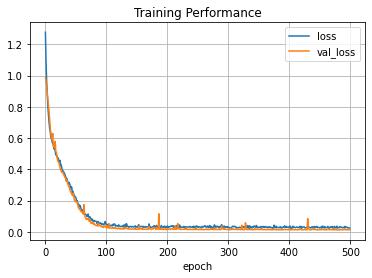

In [51]:
#Plot Training Results
hist_df = pd.DataFrame(history.history)
hist_df.plot()
plt.grid(True)
plt.title('Training Performance')
plt.xlabel('epoch')
plt.show()

In [52]:
#predict using test data
X_pred_enc = encoder.predict(X_test)
X_pred_dec = decoder.predict(X_pred_enc)

In [53]:
#build a dataframe to store the data as csv
df = pd.DataFrame(np.concatenate((param_test, X_pred_enc),axis=1), columns=['param_0','param_1','latent_feature'])
df.head()

#save data to csv (if needed)
df.to_csv('labeled_data.csv', index=False)

In [54]:
#Generate Test Encodings

test_encodings = np.array([-1,-0.5, 0, 0.5, 1]).reshape(-1,1)
test_decoder = decoder.predict(tf.constant(test_encodings))

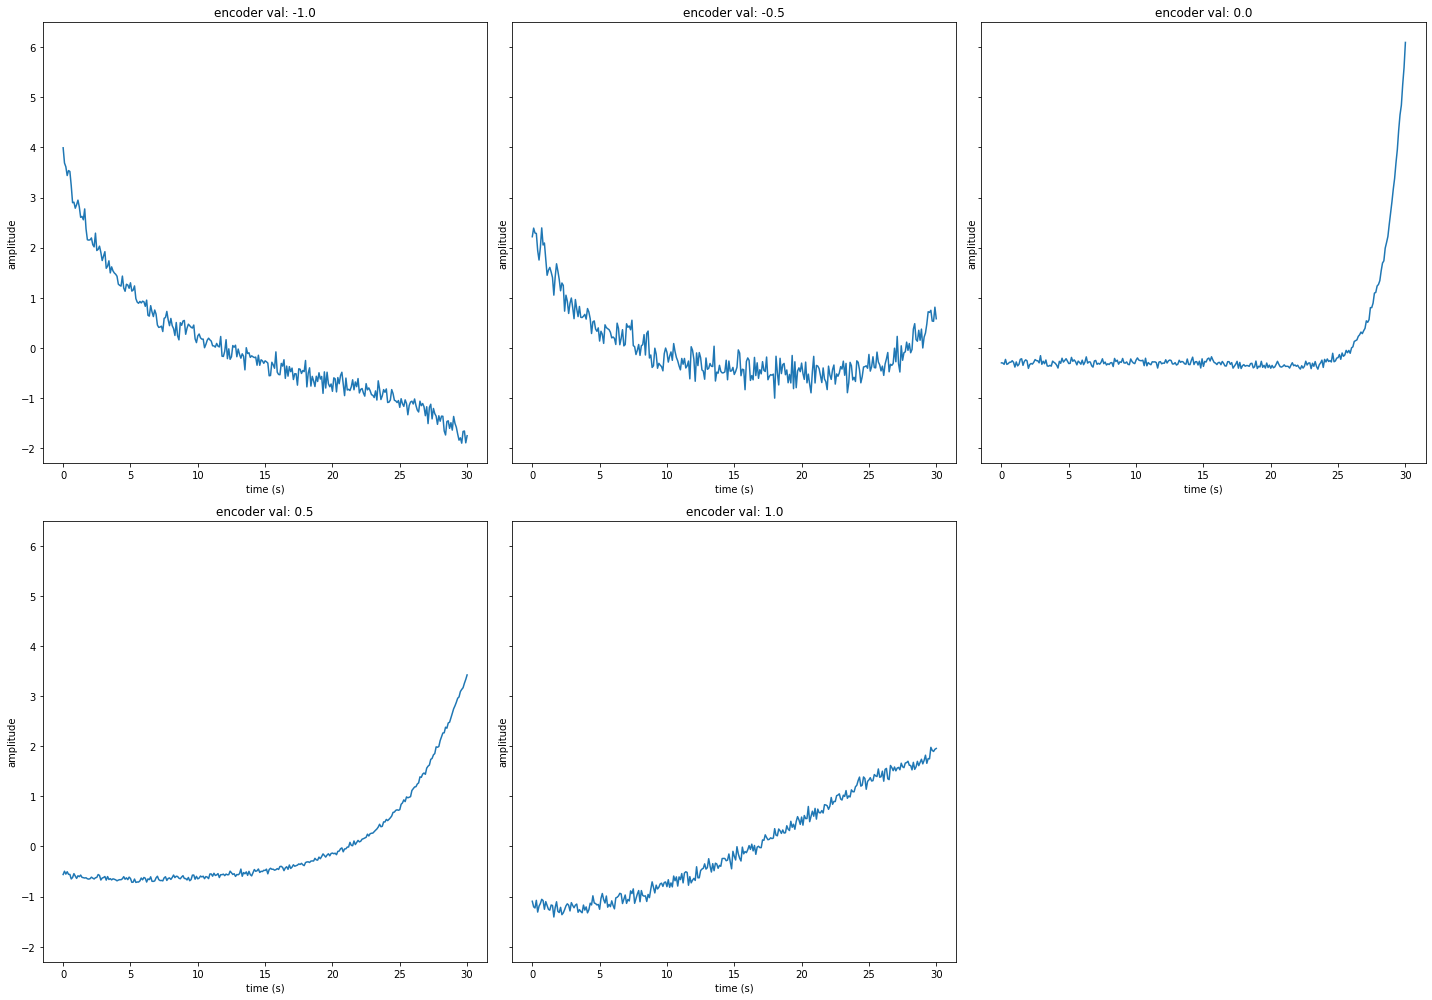

In [55]:
#Plot Decoded Test Encodings

num_plots = len(test_encodings)
fig, ax = plt.subplots(2, 3, sharey=True, figsize=(20,14))
ax = ax.flatten()
ax[len(ax)-1].remove()    #don't display empty axis
for i in range(0,num_plots):
    ax[i].plot(t,test_decoder[i,:])
    ax[i].set_xlabel('time (s)')
    ax[i].set_ylabel('amplitude')
    ax[i].set_title('encoder val: ' + str(test_encodings[i][0]))
    
fig.tight_layout()

#Save figure (if needed)
plt.savefig('Decoded_test_encodings.png')

plt.show()

Encoder value:  [0.24257782]
Parameters that generated the test data:  [-0.44295562103146047, -0.02394144346451632]


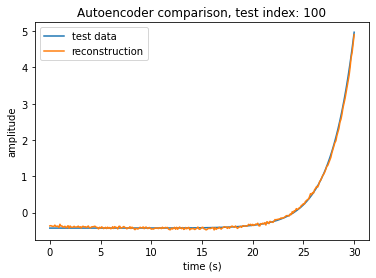

In [56]:
#Compare AutoEncoder to Test Data

idx = 100    #index of test data to plot
print("Encoder value: ", X_pred_enc[idx])
print("Parameters that generated the test data: ", param_test[idx])
plt.plot(t,X_test[idx], label='test data')
plt.plot(t,X_pred_dec[idx], label='reconstruction')
plt.xlabel('time (s)')
plt.ylabel('amplitude')
plt.title('Autoencoder comparison, test index: ' + str(idx))
plt.legend()

#save figure if necessary
plt.savefig('autoencoder_test_idx_'+str(idx)+'.png')

plt.show()